# Urban Air Quality Trend Analysis Across Indian Metro Cities
This notebook performs an exploratory data analysis (EDA) and trend analysis of air quality across major Indian metro cities using the `INDIA_AQI_COMPLETE_20251126.csv` dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Data Loading & Preprocessing
We will load the dataset, filter it for the selected metro cities, and handle the datetime parsing.


In [2]:
# Selected Metro Cities
metro_cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Chennai', 'Kolkata', 'Hyderabad', 'Ahmedabad']

# Load dataset and filter for metro cities
cols_to_use = ['City', 'Datetime', 'Year', 'Month', 'Season', 'Temp_2m_C', 'Humidity_Percent', 'Wind_Speed_10m_kmh', 'PM2_5_ugm3', 'PM10_ugm3', 'US_AQI']
df = pd.read_csv('INDIA_AQI_COMPLETE_20251126.csv', usecols=cols_to_use)

df_metro = df[df['City'].isin(metro_cities)].copy()

# Parse Datetime
df_metro['Datetime'] = pd.to_datetime(df_metro['Datetime'])
df_metro.sort_values('Datetime', inplace=True)

print(f"Data loaded and filtered. Total records: {len(df_metro)}")
df_metro.head()


Data loaded and filtered. Total records: 203280


,City,Datetime,Year,Month,Season,Temp_2m_C,Humidity_Percent,Wind_Speed_10m_kmh,PM2_5_ugm3,PM10_ugm3,US_AQI
29040,Ahmedabad,2022-08-05,2022,8,Monsoon,26.0,95,6.0,25.9,38.0,NaN
261360,Delhi,2022-08-05,2022,8,Monsoon,26.5,94,7.1,35.5,51.7,NaN
377520,Hyderabad,2022-08-05,2022,8,Monsoon,23.3,93,10.9,16.9,24.0,NaN
580800,Mumbai,2022-08-05,2022,8,Monsoon,26.2,91,6.8,15.3,23.7,NaN
203280,Chennai,2022-08-05,2022,8,Monsoon,25.1,91,10.8,21.8,31.2,NaN


## 2. Long-term Trend Analysis
Visualizing the long-term trend of AQI across different cities.


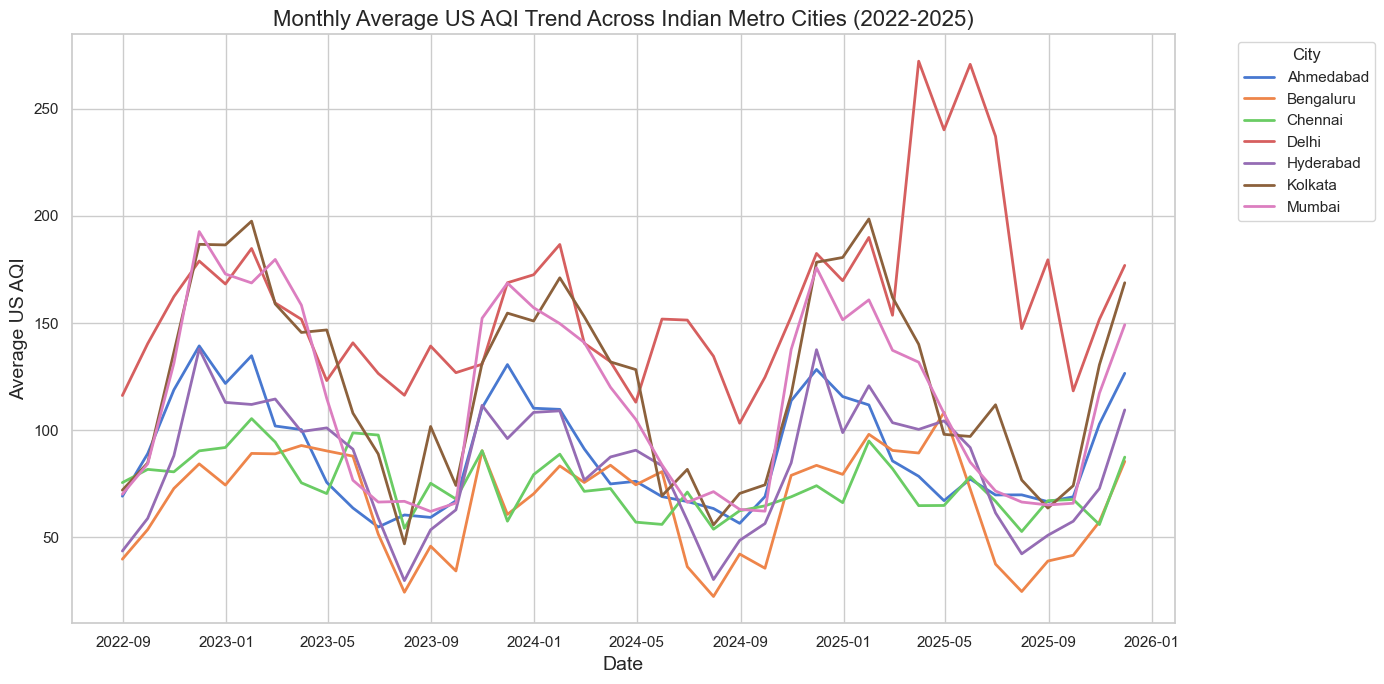

In [3]:
# Resample to monthly frequency and plot US_AQI trend
monthly_aqi = df_metro.groupby(['City', pd.Grouper(key='Datetime', freq='ME')])['US_AQI'].mean().unstack(level=0)

plt.figure(figsize=(14, 7))
for city in monthly_aqi.columns:
    plt.plot(monthly_aqi.index, monthly_aqi[city], label=city, linewidth=2)

plt.title('Monthly Average US AQI Trend Across Indian Metro Cities (2022-2025)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Average US AQI', fontsize=14)
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('trend_analysis.png', dpi=300)
plt.show()


## 3. Comparative City Analysis
Distribution of PM2.5 and AQI across cities.


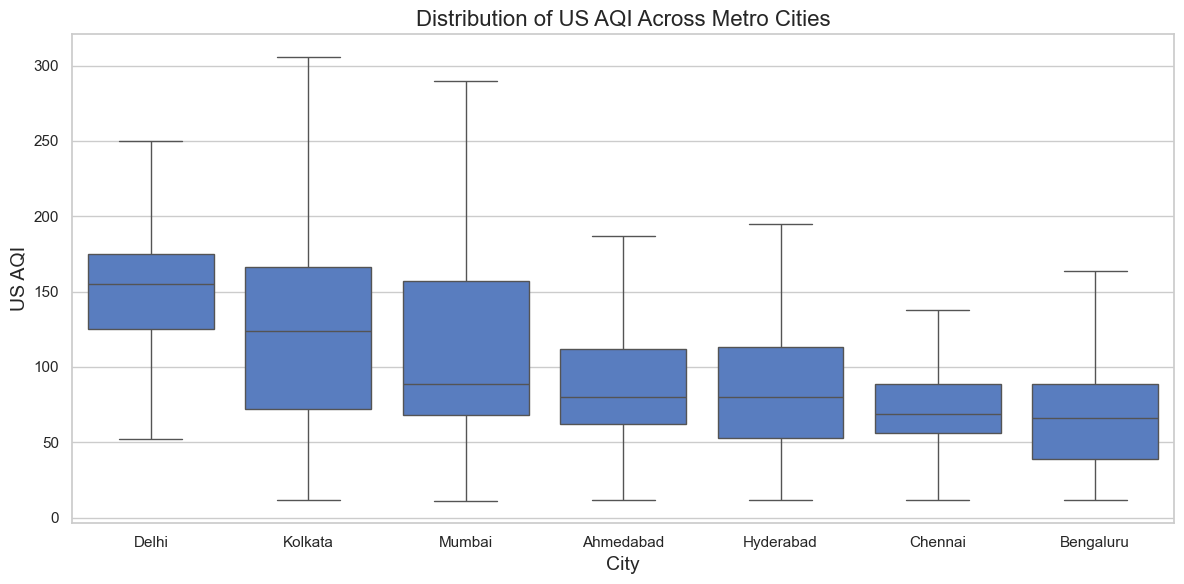

In [4]:
# Boxplot of US_AQI by City
plt.figure(figsize=(12, 6))
order = df_metro.groupby('City')['US_AQI'].median().sort_values(ascending=False).index
sns.boxplot(x='City', y='US_AQI', data=df_metro, order=order, showfliers=False)
plt.title('Distribution of US AQI Across Metro Cities', fontsize=16)
plt.xlabel('City', fontsize=14)
plt.ylabel('US AQI', fontsize=14)
plt.tight_layout()
plt.savefig('comparative_boxplot.png', dpi=300)
plt.show()


## 4. Seasonal Variations
Analyzing how AQI changes across different seasons.


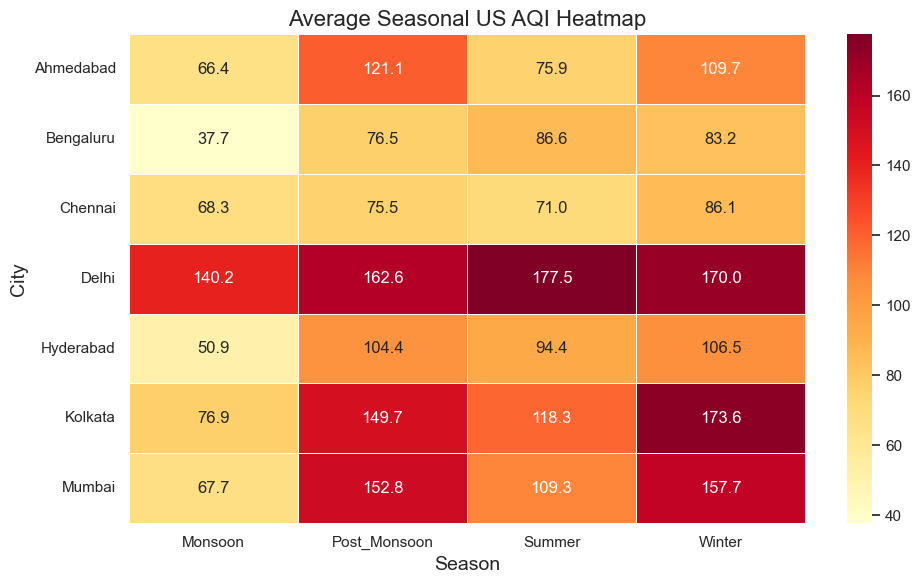

In [5]:
# Calculate mean AQI per season per city
seasonal_aqi = df_metro.groupby(['City', 'Season'])['US_AQI'].mean().unstack()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(seasonal_aqi, annot=True, cmap='YlOrRd', fmt=".1f", linewidths=.5)
plt.title('Average Seasonal US AQI Heatmap', fontsize=16)
plt.xlabel('Season', fontsize=14)
plt.ylabel('City', fontsize=14)
plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=300)
plt.show()


## 5. Meteorological Correlation
Correlation between AQI and meteorological factors.


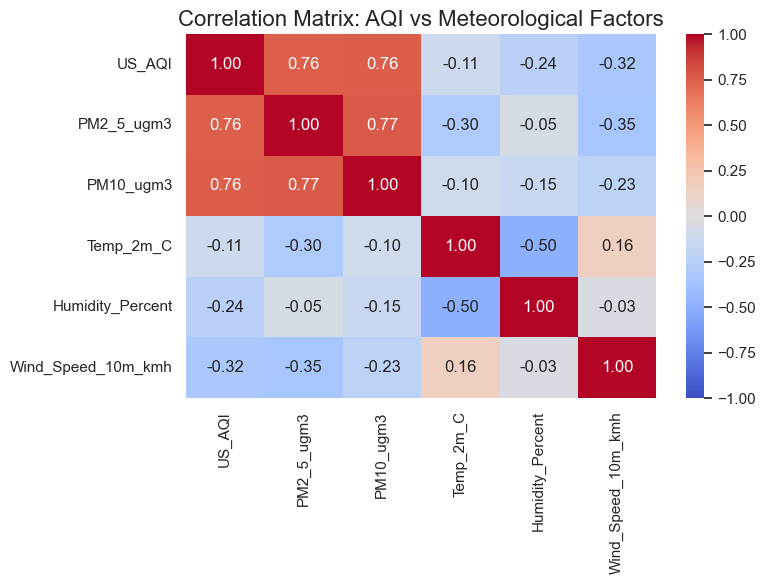

In [6]:
# Correlation matrix
corr_cols = ['US_AQI', 'PM2_5_ugm3', 'PM10_ugm3', 'Temp_2m_C', 'Humidity_Percent', 'Wind_Speed_10m_kmh']
corr_matrix = df_metro[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: AQI vs Meteorological Factors', fontsize=16)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()
